In [2]:
import numpy as np
import torch 
import matplotlib.pyplot as plt


In [43]:
T = 100
dt = 0.1
n_T = int ( T / dt )

S = 1000

D_in = 1
D_out = 1

beta = 10000
alpha = (n_T / dt) * (D_out / beta)
gamma = 1
x_0 = 0
rho, rho_hat, omega, omega_hat = 1e-3, 1e-3, 1e-3, 1e-3
# reg = 0.01

Y_star = torch.sin(2 * torch.linspace(0, T, n_T)).unsqueeze(0)  # n_T, D_out
C_I = torch.eye(n_T)                                            # n_T, n_T
C_y = torch.einsum('na, ma -> nm', Y_star, Y_star)              # n_T, n_T

L_I = torch.linalg.cholesky(C_I)

C = torch.eye(n_T, dtype=torch.float32, requires_grad=True)     # n_T, n_T
C_hat = torch.zeros((n_T, n_T), dtype=torch.float32, requires_grad=True)  # n_T, n_T
K = torch.normal(mean=0, std=1, size=(n_T,), dtype=torch.float32, requires_grad=True)  # n_T, 
K_hat = torch.normal(mean=0, std=1, size=(n_T,), dtype=torch.float32, requires_grad=True)       # n_T,

tol = 1e-6
running = True
iter = 0
avg_grads = []
kappas = []

while running:

    B = torch.linalg.inv(                                           # n_T, n_T
        alpha * torch.eye(n_T) + C
    )
  
    u = torch.randn((S,))
    z = torch.randn((S, n_T))
    eta = torch.einsum('n, s -> sn', K, u) + torch.einsum('nk, sk -> sn', L_I, z)
    x = torch.full((S, n_T), fill_value=x_0)
    for i in range(1,n_T):
        x[:,i] = (1 - dt)*x[:,i-1] + dt*eta[:,i]

    Phi = torch.tanh( x )                                           # S, n_T

    log_W = torch.logsumexp( - torch.einsum('sn, nm, sm -> s', Phi, C_hat, Phi) , dim=0) / S

    action = (
        torch.einsum('n, n', K_hat, K) + (1/2)*torch.einsum('n, nm, m', K_hat, C, K_hat) +\
        (gamma**2 / 2) * torch.trace( torch.einsum('nk, km -> nm', B, C_y) ) +\
        torch.trace( torch.einsum('kn, km -> nm', C_hat, C) ) + log_W
    )

    with torch.no_grad():
        for p in [C, C_hat, K, K_hat]:
            if p.grad is not None:
                p.grad.zero_()

        # action += reg*torch.sum( torch.square( K ) )
        action.backward()

        C += rho*C_hat.grad
        C_hat += -rho_hat*C.grad
        K += omega*K_hat.grad
        K_hat += -omega_hat*K.grad

        avg_grad = torch.mean(
            torch.abs(
                torch.concatenate((C.grad.flatten(), C_hat.grad.flatten(), K.grad.flatten(), K_hat.grad.flatten()))
            )
        ) 
        avg_grads.append(avg_grad.detach().item())
        print(f'[{iter}] S={action.detach().numpy().item():.4f} | grad={avg_grad.detach().numpy().item():.4f} | ||K||={K.norm().detach().item():.4f}')
        
        if avg_grad < tol:
            running = False
        iter += 1

        kappas.append(K.detach())
        

[0] S=568.2991 | grad=15.7218 | ||K||=32.0025
[1] S=599.5741 | grad=15.6903 | ||K||=32.0330
[2] S=630.8490 | grad=15.6589 | ||K||=32.0636
[3] S=662.1238 | grad=15.6274 | ||K||=32.0942
[4] S=693.3985 | grad=15.5960 | ||K||=32.1249
[5] S=724.6732 | grad=15.5647 | ||K||=32.1557
[6] S=755.9478 | grad=15.5334 | ||K||=32.1865
[7] S=787.2222 | grad=15.5021 | ||K||=32.2174
[8] S=818.4965 | grad=15.4709 | ||K||=32.2483
[9] S=849.7708 | grad=15.4397 | ||K||=32.2793
[10] S=881.0448 | grad=15.4085 | ||K||=32.3104
[11] S=912.3185 | grad=15.3774 | ||K||=32.3415
[12] S=943.5922 | grad=15.3463 | ||K||=32.3727
[13] S=974.8657 | grad=15.3153 | ||K||=32.4039
[14] S=1006.1388 | grad=15.2843 | ||K||=32.4352
[15] S=1037.4119 | grad=15.2533 | ||K||=32.4666
[16] S=1068.6844 | grad=15.2224 | ||K||=32.4980
[17] S=1099.9569 | grad=15.1915 | ||K||=32.5295
[18] S=1131.2291 | grad=15.1607 | ||K||=32.5611
[19] S=1162.5010 | grad=15.1299 | ||K||=32.5927
[20] S=1193.7723 | grad=15.0991 | ||K||=32.6244
[21] S=1225.0436

KeyboardInterrupt: 

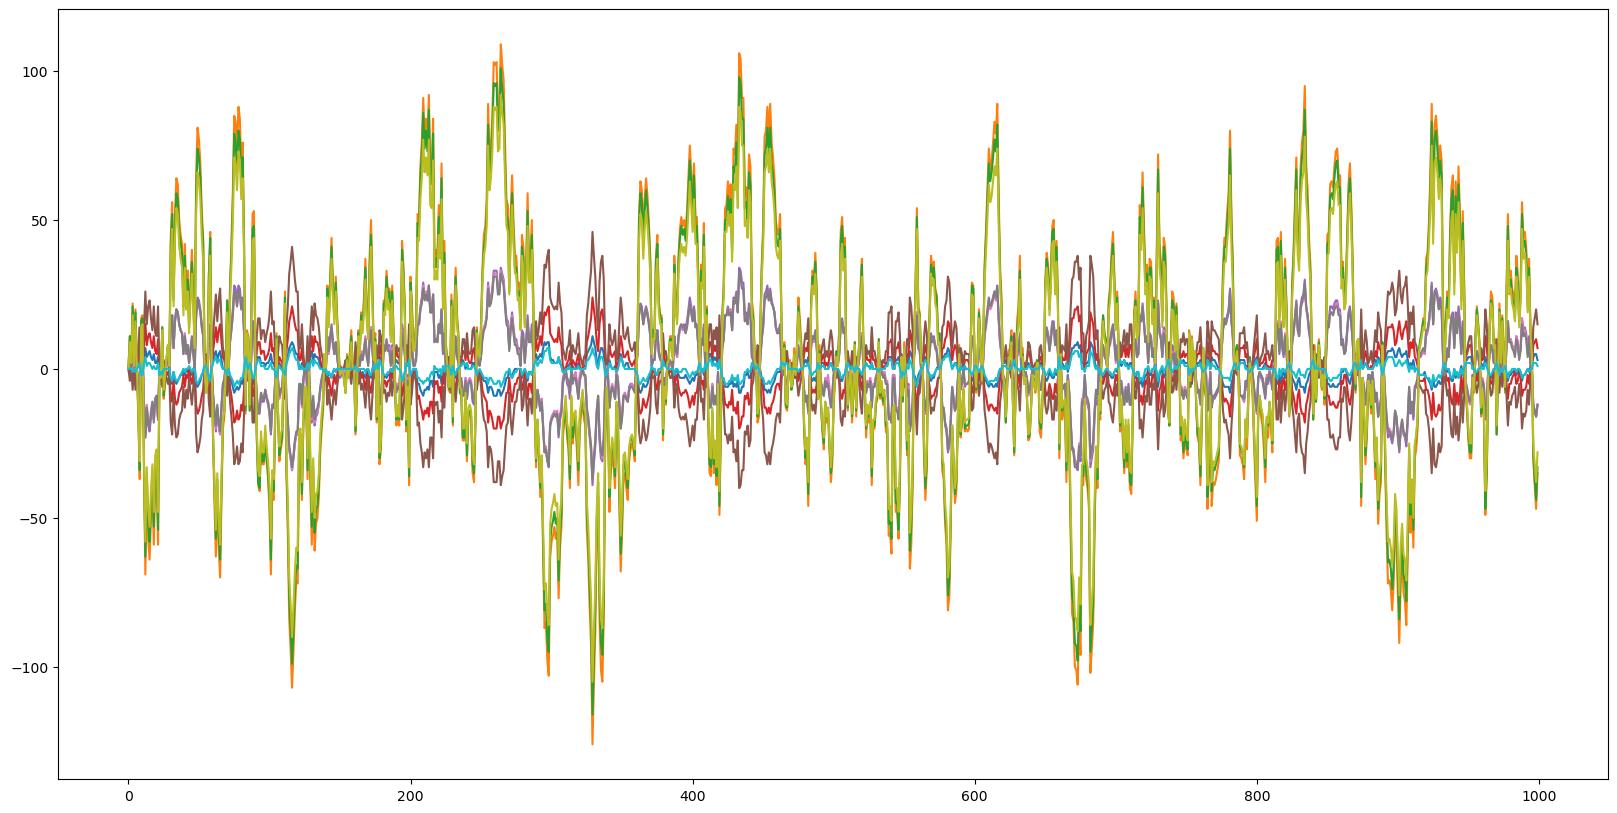

In [ ]:
S = 10

u = torch.randn((S,))
z = torch.randn((S, n_T))
eta = torch.einsum('n, s -> sn', kappas[-1], u) + torch.einsum('nk, sk -> sn', L_I, z)
x = torch.full((S, n_T), fill_value=x_0)
for i in range(1,n_T):
    x[:,i] = (1 - dt)*x[:,i-1] + dt*eta[:,i]

Phi = torch.tanh( x )

fig, ax = plt.subplots(1, 1, figsize=(20,10))

for s in range(S):
    ax.plot(Phi[s,:])
ax.plot(Y_star[:,0], ls='--')